# Reference Card Extraction

This notebook extracts the individual UNO cards from the four reference photos and writes the same output folders as before: `components`, `closed_components`, `masks`, and `crops`.

The pipeline is intentionally student-friendly: it first builds simple evidence masks from colored pixels, dark ink, edges, and local contrast, then fits fixed-size card windows around the strongest card-like regions. Run the cells from top to bottom, inspect the previews, then tune the configuration cell only if needed.

In [76]:
from dataclasses import dataclass
from math import ceil
from pathlib import Path

import cv2
import numpy as np
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve().parent
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

REFERENCE_IMAGES_DIR = PROJECT_ROOT / "data" / "iapr-26-uno-vision-challenge" / "reference_images"
REFERENCE_CARDS_DIR = PROJECT_ROOT / "project" / "training_data" / "training_images" / "reference_cards"

if not REFERENCE_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Reference image directory not found: {REFERENCE_IMAGES_DIR}")

REFERENCE_CARDS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference images: {REFERENCE_IMAGES_DIR}")
print(f"Processed outputs: {REFERENCE_CARDS_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Reference images: C:\Users\doria\Documents\EPFL\IA\iapr2026do\data\iapr-26-uno-vision-challenge\reference_images
Processed outputs: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\reference_cards


## Core Functions

The next cell defines the complete extraction pipeline. The important idea is simple: detect where the card content is, propose one fixed UNO-card rectangle per card, and save both crop images and aligned masks for later augmentation.

In [77]:
RotatedRect = tuple[tuple[float, float], tuple[float, float], float]


@dataclass(frozen=True)
class ReferenceExtractionResult:
    image_name: str
    output_dir: Path
    crops: list[Path]
    masks: list[Path]
    components: list[Path]


@dataclass(frozen=True)
class CardDetection:
    rect: RotatedRect
    score: float
    source_area: int


# Load one reference image as grayscale + RGB.
def load_reference_image(
    image_name: str,
    image_dir: Path = REFERENCE_IMAGES_DIR,
) -> tuple[np.ndarray, np.ndarray]:
    image_path = image_dir / f"{image_name}.jpg"
    gray = np.array(Image.open(image_path).convert("L"))
    color_bgr = cv2.imread(str(image_path))
    if color_bgr is None:
        raise FileNotFoundError(f"Cannot read reference image: {image_path}")
    return gray, cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)


# OpenCV kernels here should be odd and positive.
def _odd(value: float) -> int:
    v = max(3, int(round(value)))
    return v if v % 2 == 1 else v + 1


# Normalize OpenCV rotated rectangles to a long-side-first representation.
def _normalize_rotated_rect(rect: RotatedRect) -> RotatedRect:
    (cx, cy), (rw, rh), angle = rect
    rw_f, rh_f, angle_f = float(rw), float(rh), float(angle)
    if rw_f < rh_f:
        rw_f, rh_f = rh_f, rw_f
        angle_f -= 90.0

    while angle_f < -90.0:
        angle_f += 180.0
    while angle_f >= 90.0:
        angle_f -= 180.0

    return ((float(cx), float(cy)), (rw_f, rh_f), angle_f)


# Binary mask for a plain rotated rectangle. Used for fast scoring.
def _rotated_rect_mask(shape: tuple[int, int], rect: RotatedRect) -> np.ndarray:
    mask = np.zeros(shape, dtype=np.uint8)
    box = cv2.boxPoints(_normalize_rotated_rect(rect)).astype(np.int32)
    cv2.fillConvexPoly(mask, box, 255)
    return mask


# Upright rounded-rectangle mask, used for final crop masks.
def _upright_rounded_rect_mask(
    height: int,
    width: int,
    rounded_corner_ratio: float,
) -> np.ndarray:
    height = max(1, int(round(height)))
    width = max(1, int(round(width)))
    mask = np.zeros((height, width), dtype=np.uint8)

    radius = int(round(min(height, width) * rounded_corner_ratio))
    radius = min(max(radius, 0), (min(height, width) - 1) // 2)

    if radius <= 0:
        mask[:, :] = 255
        return mask

    cv2.rectangle(mask, (radius, 0), (width - radius - 1, height - 1), 255, thickness=-1)
    cv2.rectangle(mask, (0, radius), (width - 1, height - radius - 1), 255, thickness=-1)
    cv2.circle(mask, (radius, radius), radius, 255, thickness=-1)
    cv2.circle(mask, (width - radius - 1, radius), radius, 255, thickness=-1)
    cv2.circle(mask, (radius, height - radius - 1), radius, 255, thickness=-1)
    cv2.circle(mask, (width - radius - 1, height - radius - 1), radius, 255, thickness=-1)
    return mask


# Rounded rotated rectangle on the full reference image canvas.
def _rounded_rotated_rect_mask(
    shape: tuple[int, int],
    rect: RotatedRect,
    rounded_corner_ratio: float,
) -> np.ndarray:
    canvas_h, canvas_w = shape
    (cx, cy), (long_side, short_side), angle = _normalize_rotated_rect(rect)

    local_w = max(1, int(round(long_side)))
    local_h = max(1, int(round(short_side)))
    local_mask = _upright_rounded_rect_mask(local_h, local_w, rounded_corner_ratio)

    canvas = np.zeros((canvas_h, canvas_w), dtype=np.uint8)
    x0 = int(round(cx - local_w / 2))
    y0 = int(round(cy - local_h / 2))
    x1 = x0 + local_w
    y1 = y0 + local_h

    dst_x0 = max(0, x0)
    dst_y0 = max(0, y0)
    dst_x1 = min(canvas_w, x1)
    dst_y1 = min(canvas_h, y1)
    if dst_x1 <= dst_x0 or dst_y1 <= dst_y0:
        return canvas

    src_x0 = dst_x0 - x0
    src_y0 = dst_y0 - y0
    src_x1 = src_x0 + (dst_x1 - dst_x0)
    src_y1 = src_y0 + (dst_y1 - dst_y0)
    canvas[dst_y0:dst_y1, dst_x0:dst_x1] = local_mask[src_y0:src_y1, src_x0:src_x1]

    rotation = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    return cv2.warpAffine(
        canvas,
        cv2.invertAffineTransform(rotation),
        (canvas_w, canvas_h),
        flags=cv2.INTER_NEAREST,
        borderValue=0,
    )


# Remove tiny connected components from a binary mask.
def _remove_small_components(mask: np.ndarray, min_area_abs: int) -> np.ndarray:
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    for label in range(1, n_labels):
        if int(stats[label, cv2.CC_STAT_AREA]) >= int(min_area_abs):
            cleaned[labels == label] = 255
    return cleaned


# Build only step 2 (colored pixels + dark ink), then clean it for candidate generation.
def _build_card_evidence_masks(
    color_rgb: np.ndarray,
    saturation_min: int = 35,
    dark_max: int = 175,
    color_value_min: int = 60,
    cleanup_close_size: int = 19,
    cleanup_dilate_size: int = 3,
    min_component_area_abs: int = 5000,
) -> dict[str, np.ndarray]:
    if color_rgb.ndim == 2:
        color_rgb = cv2.cvtColor(color_rgb, cv2.COLOR_GRAY2RGB)

    gray = cv2.cvtColor(color_rgb, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(color_rgb, cv2.COLOR_RGB2HSV)

    colored = ((hsv[:, :, 1] >= int(saturation_min)) & (hsv[:, :, 2] >= int(color_value_min))).astype(np.uint8) * 255
    dark = (gray <= int(dark_max)).astype(np.uint8) * 255
    ink_or_color = cv2.bitwise_or(colored, dark)

    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (_odd(cleanup_close_size), _odd(cleanup_close_size)))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (_odd(cleanup_dilate_size), _odd(cleanup_dilate_size)))
    clean = cv2.morphologyEx(ink_or_color, cv2.MORPH_CLOSE, close_kernel, iterations=1)
    clean = cv2.dilate(clean, dilate_kernel, iterations=1)
    clean = _remove_small_components(clean, min_component_area_abs)

    return {
        "ink_or_color": ink_or_color,
        "evidence": ink_or_color,
        "clean": clean,
    }


# Fit one rotated rectangle around every card-like connected component.
def _component_rects(
    clean_mask: np.ndarray,
    min_component_area_abs: int,
) -> list[tuple[int, RotatedRect]]:
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean_mask, connectivity=8)
    components: list[tuple[int, RotatedRect]] = []

    for label in range(1, n_labels):
        area = int(stats[label, cv2.CC_STAT_AREA])
        if area < int(min_component_area_abs):
            continue

        component = np.zeros_like(clean_mask)
        component[labels == label] = 255
        contours, _ = cv2.findContours(component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        rect = _normalize_rotated_rect(cv2.minAreaRect(np.vstack(contours)))
        components.append((area, rect))

    return components


# Evidence coverage inside one proposed card window.
def _score_card_rect(evidence_mask: np.ndarray, rect: RotatedRect) -> float:
    rect_mask = _rotated_rect_mask(evidence_mask.shape, rect)
    inside = rect_mask > 0
    if not np.any(inside):
        return 0.0
    return float(np.mean(evidence_mask[inside] > 0))


# Generate fixed-size card candidates. Large connected components are split along their long axis.
def _generate_card_candidates(
    clean_mask: np.ndarray,
    evidence_mask: np.ndarray,
    source_card_width: int = 375,
    source_card_height: int = 580,
    max_cards_per_component: int = 4,
    center_search_fraction: float = 0.10,
    angle_jitter_deg: float = 2.0,
    min_component_area_abs: int = 5000,
) -> list[CardDetection]:
    source_long = float(max(source_card_width, source_card_height))
    source_short = float(min(source_card_width, source_card_height))
    candidates: list[CardDetection] = []

    angle_offsets = [-float(angle_jitter_deg), 0.0, float(angle_jitter_deg)] if angle_jitter_deg > 0 else [0.0]
    center_offsets = [
        (0.0, 0.0),
        (-float(center_search_fraction), 0.0),
        (float(center_search_fraction), 0.0),
        (0.0, -float(center_search_fraction)),
        (0.0, float(center_search_fraction)),
    ]

    for area, component_rect in _component_rects(clean_mask, min_component_area_abs):
        (cx, cy), (component_long, _), angle = _normalize_rotated_rect(component_rect)
        axis_long = np.array([np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))], dtype=np.float32)

        split_count = max(1, min(int(max_cards_per_component), int(np.floor(component_long / source_long + 0.5))))
        if component_long < 1.35 * source_long:
            split_count = 1

        split_spacing = min(source_long * 1.05, component_long / max(1, split_count))
        base_centers = [
            np.array([cx, cy], dtype=np.float32) + axis_long * ((i - (split_count - 1) / 2.0) * split_spacing)
            for i in range(split_count)
        ]

        for base_center in base_centers:
            for angle_offset in angle_offsets:
                candidate_angle = angle + angle_offset
                axis_long_candidate = np.array(
                    [np.cos(np.deg2rad(candidate_angle)), np.sin(np.deg2rad(candidate_angle))],
                    dtype=np.float32,
                )
                axis_short_candidate = np.array([-axis_long_candidate[1], axis_long_candidate[0]], dtype=np.float32)

                for long_shift, short_shift in center_offsets:
                    center = base_center.copy()
                    center += axis_long_candidate * (long_shift * source_long)
                    center += axis_short_candidate * (short_shift * source_short)

                    rect = _normalize_rotated_rect(
                        (
                            (float(center[0]), float(center[1])),
                            (source_long, source_short),
                            float(candidate_angle),
                        )
                    )
                    score = _score_card_rect(evidence_mask, rect)
                    candidates.append(CardDetection(rect=rect, score=score, source_area=area))

    candidates.sort(key=lambda detection: detection.score, reverse=True)
    return candidates


# IoU between two rotated rectangles for NMS.
def _rotated_rect_iou(rect_a: RotatedRect, rect_b: RotatedRect) -> float:
    a = _normalize_rotated_rect(rect_a)
    b = _normalize_rotated_rect(rect_b)
    area_a = float(a[1][0] * a[1][1])
    area_b = float(b[1][0] * b[1][1])
    if area_a <= 0.0 or area_b <= 0.0:
        return 0.0

    _, intersection_points = cv2.rotatedRectangleIntersection(a, b)
    if intersection_points is None:
        return 0.0

    intersection_area = float(abs(cv2.contourArea(intersection_points)))
    union = area_a + area_b - intersection_area
    return intersection_area / union if union > 0.0 else 0.0


# Keep the best non-overlapping card windows.
def _select_card_detections(
    candidates: list[CardDetection],
    num_components: int,
    image_shape: tuple[int, int],
    source_card_width: int = 375,
    source_card_height: int = 580,
    nms_iou: float = 0.35,
    nms_center_distance_fraction: float = 0.55,
) -> list[CardDetection]:
    image_h, image_w = image_shape
    source_long = float(max(source_card_width, source_card_height))
    source_short = float(min(source_card_width, source_card_height))
    min_center_distance = float(nms_center_distance_fraction) * source_short

    selected: list[CardDetection] = []
    for candidate in candidates:
        (cx, cy), _, _ = candidate.rect
        if not (-source_short / 2.0 < cx < image_w + source_short / 2.0):
            continue
        if not (-source_long / 2.0 < cy < image_h + source_long / 2.0):
            continue

        duplicate = False
        for keep in selected:
            (kx, ky), _, _ = keep.rect
            center_distance = float(np.hypot(cx - kx, cy - ky))
            if center_distance < min_center_distance:
                duplicate = True
                break
            if _rotated_rect_iou(candidate.rect, keep.rect) >= float(nms_iou):
                duplicate = True
                break

        if duplicate:
            continue

        selected.append(candidate)
        if len(selected) >= int(num_components):
            break

    return selected


# Whole detection wrapper shared by preview and extraction.
def _detect_reference_cards(
    color_rgb: np.ndarray,
    num_components: int,
    saturation_min: int = 35,
    dark_max: int = 175,
    color_value_min: int = 60,
    cleanup_close_size: int = 19,
    cleanup_dilate_size: int = 3,
    min_component_area_abs: int = 5000,
    source_card_width: int = 375,
    source_card_height: int = 580,
    max_cards_per_component: int = 4,
    center_search_fraction: float = 0.10,
    angle_jitter_deg: float = 2.0,
    nms_iou: float = 0.35,
    nms_center_distance_fraction: float = 0.55,
) -> tuple[dict[str, np.ndarray], list[CardDetection]]:
    masks = _build_card_evidence_masks(
        color_rgb,
        saturation_min=saturation_min,
        dark_max=dark_max,
        color_value_min=color_value_min,
        cleanup_close_size=cleanup_close_size,
        cleanup_dilate_size=cleanup_dilate_size,
        min_component_area_abs=min_component_area_abs,
    )

    candidates = _generate_card_candidates(
        clean_mask=masks["clean"],
        evidence_mask=masks["evidence"],
        source_card_width=source_card_width,
        source_card_height=source_card_height,
        max_cards_per_component=max_cards_per_component,
        center_search_fraction=center_search_fraction,
        angle_jitter_deg=angle_jitter_deg,
        min_component_area_abs=min_component_area_abs,
    )

    detections = _select_card_detections(
        candidates,
        num_components=num_components,
        image_shape=masks["clean"].shape,
        source_card_width=source_card_width,
        source_card_height=source_card_height,
        nms_iou=nms_iou,
        nms_center_distance_fraction=nms_center_distance_fraction,
    )
    return masks, detections


# Load previous full-scene mask centers so crop numbering can stay compatible with reference.csv.
def _load_previous_centers(closed_dir: Path) -> list[tuple[int, tuple[float, float]]]:
    centers: list[tuple[int, tuple[float, float]]] = []
    if not closed_dir.exists():
        return centers

    for path in sorted(closed_dir.glob("closed_component_*.jpg"), key=lambda p: int(p.stem.split("_")[-1])):
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if mask is None or np.count_nonzero(mask > 127) == 0:
            continue

        moments = cv2.moments((mask > 127).astype(np.uint8))
        if moments["m00"] == 0:
            continue

        idx = int(path.stem.split("_")[-1])
        centers.append((idx, (moments["m10"] / moments["m00"], moments["m01"] / moments["m00"])))

    return centers


# Order detections either by old crop numbering, by reading order, or by score.
def _order_detections(
    detections: list[CardDetection],
    previous_centers: list[tuple[int, tuple[float, float]]] | None = None,
    sort_mode: str = "previous_outputs",
) -> list[CardDetection]:
    if sort_mode == "previous_outputs" and previous_centers:
        remaining = list(detections)
        ordered: list[CardDetection] = []

        for _, previous_center in previous_centers:
            if not remaining:
                break

            px, py = previous_center
            pick = min(
                remaining,
                key=lambda detection: float(
                    np.hypot(detection.rect[0][0] - px, detection.rect[0][1] - py)
                ),
            )
            ordered.append(pick)
            remaining.remove(pick)

        ordered.extend(remaining)
        return ordered

    if sort_mode == "reading_order":
        return sorted(detections, key=lambda detection: (round(detection.rect[0][1] / 300.0), detection.rect[0][0]))

    return detections


# Crop one detected card and return a portrait image with fixed output dimensions.
def _crop_rotated_card(
    img_bgr: np.ndarray,
    rect: RotatedRect,
    output_card_width: int,
    output_card_height: int,
) -> np.ndarray:
    (cx, cy), (source_long, source_short), angle = _normalize_rotated_rect(rect)
    rotation = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    warped = cv2.warpAffine(
        img_bgr,
        rotation,
        (img_bgr.shape[1], img_bgr.shape[0]),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(255, 255, 255),
    )

    crop_size = (max(1, int(round(source_long))), max(1, int(round(source_short))))
    crop = cv2.getRectSubPix(warped, crop_size, (float(cx), float(cy)))

    if crop.shape[1] > crop.shape[0]:
        crop = cv2.rotate(crop, cv2.ROTATE_90_CLOCKWISE)

    if crop.shape[1] != int(output_card_width) or crop.shape[0] != int(output_card_height):
        crop = cv2.resize(crop, (int(output_card_width), int(output_card_height)), interpolation=cv2.INTER_AREA)

    return crop


# Draw selected detections for preview.
def _render_detection_overlay(
    color_rgb: np.ndarray,
    detections: list[CardDetection],
) -> np.ndarray:
    overlay = color_rgb.copy()
    for i, detection in enumerate(detections):
        box = cv2.boxPoints(detection.rect).astype(np.int32)
        score = float(np.clip(detection.score, 0.0, 1.0))
        color = (255, int(80 + 150 * score), 20)
        cv2.polylines(overlay, [box], True, color, 8, lineType=cv2.LINE_AA)
        cx, cy = map(int, detection.rect[0])
        cv2.putText(overlay, str(i), (cx - 18, cy + 18), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 0), 8, cv2.LINE_AA)
        cv2.putText(overlay, str(i), (cx - 18, cy + 18), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (255, 255, 255), 3, cv2.LINE_AA)
    return overlay


# Keep only steps 2 and 6, then show the numbered detection overlay.
def _mask_pipeline_steps(
    color_rgb: np.ndarray,
    num_components: int,
    saturation_min: int = 35,
    dark_max: int = 175,
    color_value_min: int = 60,
    cleanup_close_size: int = 19,
    cleanup_dilate_size: int = 3,
    min_component_area_abs: int = 5000,
    source_card_width: int = 375,
    source_card_height: int = 580,
    max_cards_per_component: int = 4,
    center_search_fraction: float = 0.10,
    angle_jitter_deg: float = 2.0,
    nms_iou: float = 0.35,
    nms_center_distance_fraction: float = 0.55,
    rounded_corner_ratio: float = 0.08,
) -> dict[str, np.ndarray]:
    masks, detections = _detect_reference_cards(
        color_rgb,
        num_components=num_components,
        saturation_min=saturation_min,
        dark_max=dark_max,
        color_value_min=color_value_min,
        cleanup_close_size=cleanup_close_size,
        cleanup_dilate_size=cleanup_dilate_size,
        min_component_area_abs=min_component_area_abs,
        source_card_width=source_card_width,
        source_card_height=source_card_height,
        max_cards_per_component=max_cards_per_component,
        center_search_fraction=center_search_fraction,
        angle_jitter_deg=angle_jitter_deg,
        nms_iou=nms_iou,
        nms_center_distance_fraction=nms_center_distance_fraction,
    )

    detection_mask = np.zeros_like(masks["clean"])
    for detection in detections:
        detection_mask = cv2.bitwise_or(
            detection_mask,
            _rounded_rotated_rect_mask(masks["clean"].shape, detection.rect, rounded_corner_ratio),
        )

    return {
        "2 - Colored pixels + dark ink": masks["ink_or_color"],
        "6 - Selected fixed-size card windows": detection_mask,
        "7 - Numbered detection overlay": _render_detection_overlay(color_rgb, detections),
    }


# Main extraction: components + closed components + crop masks + crops.
def extract_reference_card_assets(
    image_name: str,
    num_components: int,
    image_dir: Path = REFERENCE_IMAGES_DIR,
    output_root: Path = REFERENCE_CARDS_DIR,
    saturation_min: int = 35,
    dark_max: int = 175,
    color_value_min: int = 60,
    cleanup_close_size: int = 19,
    cleanup_dilate_size: int = 3,
    min_component_area_abs: int = 5000,
    source_card_width: int = 375,
    source_card_height: int = 580,
    max_cards_per_component: int = 4,
    center_search_fraction: float = 0.10,
    angle_jitter_deg: float = 2.0,
    nms_iou: float = 0.35,
    nms_center_distance_fraction: float = 0.55,
    rounded_corner_ratio: float = 0.08,
    output_card_width: int = 375,
    output_card_height: int = 580,
    sort_mode: str = "previous_outputs",
) -> ReferenceExtractionResult:
    image_path = image_dir / f"{image_name}.jpg"
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read reference image: {image_path}")
    color_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    out_dir = output_root / image_name
    components_dir = out_dir / "components"
    closed_dir = out_dir / "closed_components"
    masks_dir = out_dir / "masks"
    crops_dir = out_dir / "crops"

    previous_centers = _load_previous_centers(closed_dir)

    for directory in (components_dir, closed_dir, masks_dir, crops_dir):
        directory.mkdir(parents=True, exist_ok=True)
        for path in directory.glob("*.jpg"):
            path.unlink()

    masks, detections = _detect_reference_cards(
        color_rgb,
        num_components=num_components,
        saturation_min=saturation_min,
        dark_max=dark_max,
        color_value_min=color_value_min,
        cleanup_close_size=cleanup_close_size,
        cleanup_dilate_size=cleanup_dilate_size,
        min_component_area_abs=min_component_area_abs,
        source_card_width=source_card_width,
        source_card_height=source_card_height,
        max_cards_per_component=max_cards_per_component,
        center_search_fraction=center_search_fraction,
        angle_jitter_deg=angle_jitter_deg,
        nms_iou=nms_iou,
        nms_center_distance_fraction=nms_center_distance_fraction,
    )
    detections = _order_detections(detections, previous_centers=previous_centers, sort_mode=sort_mode)

    if len(detections) != int(num_components):
        print(f"Warning: {image_name} expected {num_components} cards, detected {len(detections)}.")

    crops: list[Path] = []
    crop_masks: list[Path] = []
    components: list[Path] = []

    for i, detection in enumerate(detections):
        full_card_mask = _rounded_rotated_rect_mask(masks["clean"].shape, detection.rect, rounded_corner_ratio)
        component_mask = cv2.bitwise_and(masks["clean"], full_card_mask)
        if np.count_nonzero(component_mask) == 0:
            component_mask = cv2.bitwise_and(masks["evidence"], full_card_mask)

        component_path = components_dir / f"component_{i}.jpg"
        cv2.imwrite(str(component_path), component_mask)
        components.append(component_path)

        closed_component_path = closed_dir / f"closed_component_{i}.jpg"
        cv2.imwrite(str(closed_component_path), full_card_mask)

        crop_color = _crop_rotated_card(
            img_bgr,
            detection.rect,
            output_card_width=output_card_width,
            output_card_height=output_card_height,
        )
        crop_mask = _upright_rounded_rect_mask(output_card_height, output_card_width, rounded_corner_ratio)

        mask_path = masks_dir / f"mask_{i}.jpg"
        cv2.imwrite(str(mask_path), crop_mask)
        crop_masks.append(mask_path)

        crop_path = crops_dir / f"crop_{i}.jpg"
        cv2.imwrite(str(crop_path), crop_color)
        crops.append(crop_path)

    return ReferenceExtractionResult(image_name, out_dir, crops, crop_masks, components)


# Downsample to plot size (never upsample).
def _fit_image_for_axis(img: np.ndarray, ax, renderer) -> np.ndarray:
    bbox = ax.get_window_extent(renderer=renderer)
    h, w = img.shape[:2]
    scale = min(max(1, int(bbox.width)) / w, max(1, int(bbox.height)) / h, 1.0)
    if scale < 1.0:
        return cv2.resize(
            img,
            (max(1, int(round(w * scale))), max(1, int(round(h * scale)))),
            interpolation=cv2.INTER_AREA,
        )
    return img


# Plot exactly the simplified pipeline outputs.
def plot_pipeline_steps(
    color_rgb: np.ndarray,
    pipeline_steps: dict[str, np.ndarray],
    title: str = "",
) -> None:
    import matplotlib.pyplot as plt

    panels = list(pipeline_steps.items())
    n_cols = min(3, max(1, len(panels)))
    n_rows = max(1, ceil(len(panels) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.8 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax in axes:
        ax.axis("off")

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, (label, img) in zip(axes, panels):
        display = _fit_image_for_axis(img, ax, renderer)
        ax.imshow(display, cmap="gray" if display.ndim == 2 else None)
        ax.set_title(label, fontsize=10)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# Colored components + rounded overlay preview.
def plot_crop_preview(
    result: ReferenceExtractionResult,
    title: str = "",
    rounded_corner_ratio: float = 0.08,
) -> None:
    import matplotlib.pyplot as plt
    from matplotlib.colors import hsv_to_rgb

    _, color_rgb = load_reference_image(result.image_name)
    h, w = color_rgb.shape[:2]
    n_cards = max(len(result.components), 1)

    final_components_colored = np.zeros((h, w, 3), dtype=np.uint8)
    fill_layer = np.zeros_like(color_rgb)
    closed_union = np.zeros((h, w), dtype=bool)
    rounded_entries: list[tuple[np.ndarray, np.ndarray, int]] = []

    for i, comp_path in enumerate(result.components):
        comp = cv2.imread(str(comp_path), cv2.IMREAD_GRAYSCALE)
        closed_path = result.output_dir / "closed_components" / f"closed_component_{i}.jpg"
        closed = cv2.imread(str(closed_path), cv2.IMREAD_GRAYSCALE)
        if comp is None or closed is None:
            continue

        rgb = (np.array(hsv_to_rgb([i / n_cards, 0.85, 0.95])) * 255).astype(np.uint8)
        final_components_colored[comp > 0] = rgb

        closed_region = closed > 127
        fill_layer[closed_region] = rgb
        closed_union |= closed_region

        closed_contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if closed_contours:
            rounded_entries.append((max(closed_contours, key=cv2.contourArea), rgb, i))

    overlay = color_rgb.copy()
    alpha = 0.12
    overlay[closed_union] = (
        (1.0 - alpha) * color_rgb[closed_union] + alpha * fill_layer[closed_union]
    ).astype(np.uint8)

    for contour, rgb, i in rounded_entries:
        cv2.drawContours(overlay, [contour], -1, rgb.tolist(), 8, lineType=cv2.LINE_AA)
        moments = cv2.moments(contour)
        if moments["m00"] != 0:
            cx = int(moments["m10"] / moments["m00"])
            cy = int(moments["m01"] / moments["m00"])
            cv2.putText(overlay, str(i), (cx - 18, cy + 18), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 0), 8, cv2.LINE_AA)
            cv2.putText(overlay, str(i), (cx - 18, cy + 18), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (255, 255, 255), 3, cv2.LINE_AA)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    axes[0].imshow(_fit_image_for_axis(final_components_colored, axes[0], renderer))
    axes[0].set_title("Selected evidence inside each card")
    axes[0].axis("off")

    axes[1].imshow(_fit_image_for_axis(overlay, axes[1], renderer))
    axes[1].set_title("Reference image + numbered crop masks")
    axes[1].axis("off")

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# Optional crop grid for quick classifier-data inspection.
def plot_extracted_crops(
    result: ReferenceExtractionResult,
    title: str = "",
    n_cols: int = 8,
) -> None:
    import matplotlib.pyplot as plt

    crop_images = []
    for crop_path in result.crops:
        img = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
        if img is not None:
            crop_images.append((crop_path.stem, cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))

    if not crop_images:
        print(f"No crops found for {result.image_name}.")
        return

    n_cols = max(1, int(n_cols))
    n_rows = ceil(len(crop_images) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.0 * n_cols, 3.0 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax in axes:
        ax.axis("off")

    for ax, (label, img) in zip(axes, crop_images):
        ax.imshow(img)
        ax.set_title(label, fontsize=8)

    plt.suptitle(title or result.image_name, fontsize=12)
    plt.tight_layout()
    plt.show()

In [78]:
# Detection improvement: suppress detached shadows, then score windows using stable UNO center structure.
def _remove_shadow_components(
    ink_or_color: np.ndarray,
    colored_mask: np.ndarray,
    shadow_min_area_abs: int = 1800,
    shadow_min_colored_fraction: float = 0.04,
) -> np.ndarray:
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(ink_or_color, connectivity=8)
    filtered = np.zeros_like(ink_or_color)

    for label in range(1, n_labels):
        area = int(stats[label, cv2.CC_STAT_AREA])
        component = labels == label
        colored_ratio = float(np.count_nonzero(colored_mask[component] > 0)) / float(max(1, area))

        is_shadow_like = area >= int(shadow_min_area_abs) and colored_ratio < float(shadow_min_colored_fraction)
        if is_shadow_like:
            continue

        filtered[component] = 255

    return filtered


def _build_card_evidence_masks(
    color_rgb: np.ndarray,
    saturation_min: int = 35,
    dark_max: int = 175,
    color_value_min: int = 60,
    cleanup_close_size: int = 19,
    cleanup_dilate_size: int = 3,
    min_component_area_abs: int = 5000,
) -> dict[str, np.ndarray]:
    if color_rgb.ndim == 2:
        color_rgb = cv2.cvtColor(color_rgb, cv2.COLOR_GRAY2RGB)

    gray = cv2.cvtColor(color_rgb, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(color_rgb, cv2.COLOR_RGB2HSV)

    colored = ((hsv[:, :, 1] >= int(saturation_min)) & (hsv[:, :, 2] >= int(color_value_min))).astype(np.uint8) * 255
    dark = (gray <= int(dark_max)).astype(np.uint8) * 255

    ink_or_color_raw = cv2.bitwise_or(colored, dark)
    ink_or_color = _remove_shadow_components(ink_or_color_raw, colored)

    # Use conservative morphology so neighboring cards are not merged.
    close_size = min(_odd(cleanup_close_size), 7)
    dilate_size = min(_odd(cleanup_dilate_size), 3)
    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_size, close_size))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_size, dilate_size))

    clean = cv2.morphologyEx(ink_or_color, cv2.MORPH_CLOSE, close_kernel, iterations=1)
    clean = cv2.dilate(clean, dilate_kernel, iterations=1)
    clean = _remove_small_components(clean, min_component_area_abs)

    return {
        "ink_or_color": ink_or_color,
        "evidence": ink_or_color,
        "clean": clean,
    }


def _crop_rotated_mask_for_scoring(
    mask: np.ndarray,
    rect: RotatedRect,
    output_card_width: int,
    output_card_height: int,
) -> np.ndarray:
    (cx, cy), (source_long, source_short), angle = _normalize_rotated_rect(rect)
    rotation = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    warped = cv2.warpAffine(
        mask,
        rotation,
        (mask.shape[1], mask.shape[0]),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )

    crop_size = (max(1, int(round(source_long))), max(1, int(round(source_short))))
    crop = cv2.getRectSubPix(warped, crop_size, (float(cx), float(cy)))

    if crop.shape[1] > crop.shape[0]:
        crop = cv2.rotate(crop, cv2.ROTATE_90_CLOCKWISE)

    if crop.shape[1] != int(output_card_width) or crop.shape[0] != int(output_card_height):
        crop = cv2.resize(crop, (int(output_card_width), int(output_card_height)), interpolation=cv2.INTER_NEAREST)

    return crop


def _score_card_rect(
    evidence_mask: np.ndarray,
    rect: RotatedRect,
    source_card_width: int,
    source_card_height: int,
) -> float:
    patch = _crop_rotated_mask_for_scoring(
        evidence_mask,
        rect,
        output_card_width=source_card_width,
        output_card_height=source_card_height,
    )
    patch_bin = patch > 0
    if not np.any(patch_bin):
        return 0.0

    h, w = patch_bin.shape
    overall = float(np.mean(patch_bin))

    # UNO cards have a stable center structure (center number area and middle separators).
    c_y0, c_y1 = int(0.33 * h), int(0.67 * h)
    c_x0, c_x1 = int(0.18 * w), int(0.82 * w)
    center_score = float(np.mean(patch_bin[c_y0:c_y1, c_x0:c_x1]))

    b_y0, b_y1 = int(0.42 * h), int(0.58 * h)
    left_bridge = float(np.mean(patch_bin[b_y0:b_y1, int(0.03 * w):int(0.15 * w)]))
    right_bridge = float(np.mean(patch_bin[b_y0:b_y1, int(0.85 * w):int(0.97 * w)]))
    bridge_score = 0.5 * (left_bridge + right_bridge)

    # Corners should stay relatively clean because of the rounded white border.
    ch, cw = max(1, int(0.14 * h)), max(1, int(0.14 * w))
    corner_pixels = np.concatenate(
        [
            patch_bin[:ch, :cw].ravel(),
            patch_bin[:ch, -cw:].ravel(),
            patch_bin[-ch:, :cw].ravel(),
            patch_bin[-ch:, -cw:].ravel(),
        ]
    )
    corner_penalty = float(np.mean(corner_pixels))

    return 0.45 * overall + 0.35 * center_score + 0.30 * bridge_score - 0.25 * corner_penalty


def _generate_card_candidates(
    clean_mask: np.ndarray,
    evidence_mask: np.ndarray,
    source_card_width: int = 375,
    source_card_height: int = 580,
    max_cards_per_component: int = 12,
    center_search_fraction: float = 0.10,
    angle_jitter_deg: float = 2.0,
    min_component_area_abs: int = 5000,
) -> list[CardDetection]:
    source_long = float(max(source_card_width, source_card_height))
    source_short = float(min(source_card_width, source_card_height))
    source_area = source_long * source_short
    candidates: list[CardDetection] = []

    angle_offsets = [-float(angle_jitter_deg), 0.0, float(angle_jitter_deg)] if angle_jitter_deg > 0 else [0.0]
    center_offsets = [
        (0.0, 0.0),
        (-float(center_search_fraction), 0.0),
        (float(center_search_fraction), 0.0),
        (0.0, -float(center_search_fraction)),
        (0.0, float(center_search_fraction)),
    ]

    for area, component_rect in _component_rects(clean_mask, min_component_area_abs):
        (cx, cy), (component_long, component_short), angle = _normalize_rotated_rect(component_rect)
        axis_long = np.array([np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))], dtype=np.float32)
        axis_short = np.array([-axis_long[1], axis_long[0]], dtype=np.float32)

        long_based = int(np.floor(component_long / source_long + 0.5))
        area_based = int(np.floor(area / max(1.0, source_area * 0.50) + 0.5))
        grid_long = max(1, int(np.floor(component_long / source_long + 0.5)))
        grid_short = max(1, int(np.floor(component_short / source_short + 0.5)))
        grid_based = grid_long * grid_short

        split_count = max(1, min(int(max_cards_per_component), max(long_based, area_based, grid_based)))
        if component_long < 1.30 * source_long and component_short < 1.25 * source_short:
            split_count = 1

        base_centers: list[np.ndarray] = []
        if split_count == 1:
            base_centers = [np.array([cx, cy], dtype=np.float32)]
        else:
            long_count = max(1, int(round(np.sqrt(split_count * component_long / max(component_short, 1.0)))))
            short_count = max(1, int(np.ceil(split_count / max(1, long_count))))
            long_spacing = min(source_long * 1.05, component_long / max(1, long_count))
            short_spacing = min(source_short * 1.05, component_short / max(1, short_count))

            for sj in range(short_count):
                for li in range(long_count):
                    if len(base_centers) >= split_count:
                        break
                    long_shift = (li - (long_count - 1) / 2.0) * long_spacing
                    short_shift = (sj - (short_count - 1) / 2.0) * short_spacing
                    center = np.array([cx, cy], dtype=np.float32)
                    center += axis_long * long_shift
                    center += axis_short * short_shift
                    base_centers.append(center)

        for base_center in base_centers:
            for angle_offset in angle_offsets:
                candidate_angle = angle + angle_offset
                axis_long_candidate = np.array(
                    [np.cos(np.deg2rad(candidate_angle)), np.sin(np.deg2rad(candidate_angle))],
                    dtype=np.float32,
                )
                axis_short_candidate = np.array([-axis_long_candidate[1], axis_long_candidate[0]], dtype=np.float32)

                for long_shift, short_shift in center_offsets:
                    center = base_center.copy()
                    center += axis_long_candidate * (long_shift * source_long)
                    center += axis_short_candidate * (short_shift * source_short)

                    rect = _normalize_rotated_rect(
                        (
                            (float(center[0]), float(center[1])),
                            (source_long, source_short),
                            float(candidate_angle),
                        )
                    )
                    score = _score_card_rect(
                        evidence_mask,
                        rect,
                        source_card_width=source_card_width,
                        source_card_height=source_card_height,
                    )
                    candidates.append(CardDetection(rect=rect, score=score, source_area=area))

    candidates.sort(key=lambda detection: detection.score, reverse=True)
    return candidates

In [ ]:
# Additional candidate generator: recover multiple card centers even when components merge.
def _peak_card_centers(
    clean_mask: np.ndarray,
    source_short: float,
    max_centers: int,
) -> list[tuple[float, float]]:
    binary = (clean_mask > 0).astype(np.uint8)
    if np.count_nonzero(binary) == 0:
        return []

    dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    if float(dist.max()) <= 0.0:
        return []

    local_kernel = max(9, _odd(source_short * 0.30))
    local_max = dist == cv2.dilate(dist, np.ones((local_kernel, local_kernel), dtype=np.float32))
    threshold = dist > max(6.0, source_short * 0.12)
    ys, xs = np.where(local_max & threshold)

    if ys.size == 0:
        return []

    order = np.argsort(dist[ys, xs])[::-1]
    min_distance = source_short * 0.45
    centers: list[tuple[float, float]] = []

    for idx in order:
        x = float(xs[idx])
        y = float(ys[idx])
        if any(np.hypot(x - cx, y - cy) < min_distance for cx, cy in centers):
            continue
        centers.append((x, y))
        if len(centers) >= int(max_centers):
            break

    return centers


def _generate_card_candidates(
    clean_mask: np.ndarray,
    evidence_mask: np.ndarray,
    source_card_width: int = 375,
    source_card_height: int = 580,
    max_cards_per_component: int = 12,
    center_search_fraction: float = 0.10,
    angle_jitter_deg: float = 2.0,
    min_component_area_abs: int = 5000,
) -> list[CardDetection]:
    source_long = float(max(source_card_width, source_card_height))
    source_short = float(min(source_card_width, source_card_height))
    source_area = source_long * source_short
    candidates: list[CardDetection] = []

    angle_offsets = [-float(angle_jitter_deg), 0.0, float(angle_jitter_deg)] if angle_jitter_deg > 0 else [0.0]
    center_offsets = [
        (0.0, 0.0),
        (-float(center_search_fraction), 0.0),
        (float(center_search_fraction), 0.0),
        (0.0, -float(center_search_fraction)),
        (0.0, float(center_search_fraction)),
    ]

    component_rects = _component_rects(clean_mask, min_component_area_abs)

    # 1) Component-driven proposals.
    for area, component_rect in component_rects:
        (cx, cy), (component_long, component_short), angle = _normalize_rotated_rect(component_rect)
        axis_long = np.array([np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))], dtype=np.float32)
        axis_short = np.array([-axis_long[1], axis_long[0]], dtype=np.float32)

        long_based = int(np.floor(component_long / source_long + 0.5))
        area_based = int(np.floor(area / max(1.0, source_area * 0.50) + 0.5))
        grid_long = max(1, int(np.floor(component_long / source_long + 0.5)))
        grid_short = max(1, int(np.floor(component_short / source_short + 0.5)))
        grid_based = grid_long * grid_short

        split_count = max(1, min(int(max_cards_per_component), max(long_based, area_based, grid_based)))
        if component_long < 1.30 * source_long and component_short < 1.25 * source_short:
            split_count = 1

        base_centers: list[np.ndarray] = []
        if split_count == 1:
            base_centers = [np.array([cx, cy], dtype=np.float32)]
        else:
            long_count = max(1, int(round(np.sqrt(split_count * component_long / max(component_short, 1.0)))))
            short_count = max(1, int(np.ceil(split_count / max(1, long_count))))
            long_spacing = min(source_long * 1.05, component_long / max(1, long_count))
            short_spacing = min(source_short * 1.05, component_short / max(1, short_count))

            for sj in range(short_count):
                for li in range(long_count):
                    if len(base_centers) >= split_count:
                        break
                    long_shift = (li - (long_count - 1) / 2.0) * long_spacing
                    short_shift = (sj - (short_count - 1) / 2.0) * short_spacing
                    center = np.array([cx, cy], dtype=np.float32)
                    center += axis_long * long_shift
                    center += axis_short * short_shift
                    base_centers.append(center)

        for base_center in base_centers:
            for angle_offset in angle_offsets:
                candidate_angle = angle + angle_offset
                axis_long_candidate = np.array(
                    [np.cos(np.deg2rad(candidate_angle)), np.sin(np.deg2rad(candidate_angle))],
                    dtype=np.float32,
                )
                axis_short_candidate = np.array([-axis_long_candidate[1], axis_long_candidate[0]], dtype=np.float32)

                for long_shift, short_shift in center_offsets:
                    center = base_center.copy()
                    center += axis_long_candidate * (long_shift * source_long)
                    center += axis_short_candidate * (short_shift * source_short)

                    rect = _normalize_rotated_rect(
                        (
                            (float(center[0]), float(center[1])),
                            (source_long, source_short),
                            float(candidate_angle),
                        )
                    )
                    score = _score_card_rect(
                        evidence_mask,
                        rect,
                        source_card_width=source_card_width,
                        source_card_height=source_card_height,
                    )
                    candidates.append(CardDetection(rect=rect, score=score, source_area=area))

    # 2) Peak-driven proposals from the clean mask (helps when many cards are merged together).
    angle_seeds = sorted({round(rect[2] / 5.0) * 5.0 for _, rect in component_rects})
    if not angle_seeds:
        angle_seeds = [-20.0, -10.0, 0.0, 10.0, 20.0]
    if len(angle_seeds) > 8:
        angle_seeds = angle_seeds[:: max(1, len(angle_seeds) // 8)]

    peak_centers = _peak_card_centers(
        clean_mask,
        source_short=source_short,
        max_centers=max(24, int(max_cards_per_component) * 3),
    )

    for cx, cy in peak_centers:
        for angle in angle_seeds:
            rect = _normalize_rotated_rect(((cx, cy), (source_long, source_short), float(angle)))
            score = _score_card_rect(
                evidence_mask,
                rect,
                source_card_width=source_card_width,
                source_card_height=source_card_height,
            )
            candidates.append(CardDetection(rect=rect, score=score, source_area=0))

    candidates.sort(key=lambda detection: detection.score, reverse=True)
    return candidates

In [80]:
# Coverage-aware selection: prefer windows that explain new evidence regions.
def _select_card_detections(
    candidates: list[CardDetection],
    num_components: int,
    image_shape: tuple[int, int],
    source_card_width: int = 375,
    source_card_height: int = 580,
    nms_iou: float = 0.22,
    nms_center_distance_fraction: float = 0.40,
    evidence_mask: np.ndarray | None = None,
) -> list[CardDetection]:
    image_h, image_w = image_shape
    source_long = float(max(source_card_width, source_card_height))
    source_short = float(min(source_card_width, source_card_height))
    min_center_distance = float(nms_center_distance_fraction) * source_short

    evidence_binary = (evidence_mask > 0) if evidence_mask is not None else None
    covered = np.zeros(image_shape, dtype=bool)

    remaining = list(candidates)
    selected: list[CardDetection] = []

    def _inside_canvas(rect: RotatedRect) -> bool:
        (cx, cy), _, _ = rect
        return (-source_short / 2.0 < cx < image_w + source_short / 2.0) and (
            -source_long / 2.0 < cy < image_h + source_long / 2.0
        )

    def _is_duplicate(candidate_rect: RotatedRect) -> bool:
        (cx, cy), _, _ = candidate_rect
        for keep in selected:
            (kx, ky), _, _ = keep.rect
            center_distance = float(np.hypot(cx - kx, cy - ky))
            if center_distance < min_center_distance:
                return True
            if _rotated_rect_iou(candidate_rect, keep.rect) >= float(nms_iou):
                return True
        return False

    while remaining and len(selected) < int(num_components):
        best_idx = None
        best_metric = -1e9

        # Limit scan per round for speed while keeping strong proposals.
        for idx, candidate in enumerate(remaining[:700]):
            if not _inside_canvas(candidate.rect):
                continue
            if _is_duplicate(candidate.rect):
                continue

            metric = float(candidate.score)
            if evidence_binary is not None:
                candidate_mask = _rotated_rect_mask(image_shape, candidate.rect) > 0
                support = candidate_mask & evidence_binary
                support_count = int(np.count_nonzero(support))
                if support_count == 0:
                    continue
                new_support_count = int(np.count_nonzero(support & (~covered)))
                novelty = float(new_support_count) / float(support_count)
                metric = 0.60 * float(candidate.score) + 0.70 * novelty

            if metric > best_metric:
                best_metric = metric
                best_idx = idx

        if best_idx is None:
            break

        pick = remaining.pop(best_idx)
        selected.append(pick)

        if evidence_binary is not None:
            pick_mask = _rotated_rect_mask(image_shape, pick.rect) > 0
            covered |= pick_mask & evidence_binary

    return selected


def _detect_reference_cards(
    color_rgb: np.ndarray,
    num_components: int,
    saturation_min: int = 35,
    dark_max: int = 175,
    color_value_min: int = 60,
    cleanup_close_size: int = 19,
    cleanup_dilate_size: int = 3,
    min_component_area_abs: int = 5000,
    source_card_width: int = 375,
    source_card_height: int = 580,
    max_cards_per_component: int = 12,
    center_search_fraction: float = 0.10,
    angle_jitter_deg: float = 2.0,
    nms_iou: float = 0.22,
    nms_center_distance_fraction: float = 0.40,
) -> tuple[dict[str, np.ndarray], list[CardDetection]]:
    masks = _build_card_evidence_masks(
        color_rgb,
        saturation_min=saturation_min,
        dark_max=dark_max,
        color_value_min=color_value_min,
        cleanup_close_size=cleanup_close_size,
        cleanup_dilate_size=cleanup_dilate_size,
        min_component_area_abs=min_component_area_abs,
    )

    candidates = _generate_card_candidates(
        clean_mask=masks["clean"],
        evidence_mask=masks["evidence"],
        source_card_width=source_card_width,
        source_card_height=source_card_height,
        max_cards_per_component=max_cards_per_component,
        center_search_fraction=center_search_fraction,
        angle_jitter_deg=angle_jitter_deg,
        min_component_area_abs=min_component_area_abs,
    )

    detections = _select_card_detections(
        candidates,
        num_components=num_components,
        image_shape=masks["clean"].shape,
        source_card_width=source_card_width,
        source_card_height=source_card_height,
        nms_iou=nms_iou,
        nms_center_distance_fraction=nms_center_distance_fraction,
        evidence_mask=masks["evidence"],
    )
    return masks, detections

In [81]:
# Full visualization pipeline: show all intermediate steps while keeping detection logic unchanged.
def _mask_pipeline_steps(
    color_rgb: np.ndarray,
    num_components: int,
    saturation_min: int = 35,
    dark_max: int = 175,
    color_value_min: int = 60,
    cleanup_close_size: int = 19,
    cleanup_dilate_size: int = 3,
    min_component_area_abs: int = 5000,
    source_card_width: int = 375,
    source_card_height: int = 580,
    max_cards_per_component: int = 12,
    center_search_fraction: float = 0.10,
    angle_jitter_deg: float = 2.0,
    nms_iou: float = 0.22,
    nms_center_distance_fraction: float = 0.40,
    rounded_corner_ratio: float = 0.08,
    local_contrast_threshold: int = 15,
    background_blur_sigma: float = 35.0,
    edge_low_threshold: int = 50,
    edge_high_threshold: int = 120,
) -> dict[str, np.ndarray]:
    masks, detections = _detect_reference_cards(
        color_rgb,
        num_components=num_components,
        saturation_min=saturation_min,
        dark_max=dark_max,
        color_value_min=color_value_min,
        cleanup_close_size=cleanup_close_size,
        cleanup_dilate_size=cleanup_dilate_size,
        min_component_area_abs=min_component_area_abs,
        source_card_width=source_card_width,
        source_card_height=source_card_height,
        max_cards_per_component=max_cards_per_component,
        center_search_fraction=center_search_fraction,
        angle_jitter_deg=angle_jitter_deg,
        nms_iou=nms_iou,
        nms_center_distance_fraction=nms_center_distance_fraction,
    )

    gray = cv2.cvtColor(color_rgb, cv2.COLOR_RGB2GRAY)
    background = cv2.GaussianBlur(gray, (0, 0), float(background_blur_sigma))
    local_contrast = (cv2.absdiff(gray, background) > int(local_contrast_threshold)).astype(np.uint8) * 255
    edges = cv2.Canny(gray, int(edge_low_threshold), int(edge_high_threshold))

    edge_or_contrast = cv2.bitwise_or(edges, local_contrast)
    combined = cv2.bitwise_or(masks["ink_or_color"], edge_or_contrast)

    detection_mask = np.zeros_like(masks["clean"])
    for detection in detections:
        detection_mask = cv2.bitwise_or(
            detection_mask,
            _rounded_rotated_rect_mask(masks["clean"].shape, detection.rect, rounded_corner_ratio),
        )

    return {
        "1 - Local contrast against white paper": local_contrast,
        "2 - Colored pixels + dark ink": masks["ink_or_color"],
        "3 - Edges + local contrast": edge_or_contrast,
        "4 - Combined evidence": combined,
        "5 - Clean card-like components": masks["clean"],
        "6 - Selected fixed-size card windows": detection_mask,
        "7 - Numbered detection overlay": _render_detection_overlay(color_rgb, detections),
    }

## Experiment Configuration And Execution

Tune parameters below, then run preview and batch extraction cells.

In [82]:
# -- Image selection -----------------------------------------------------------
image_components = {
    "L1000765": 12,
    "L1000766": 12,
    "L1000767": 14,
    "L1000768": 16,
}

images_to_process = None
preview_image_name = "L1000768"

# -- Step 2: colored pixels + dark ink ----------------------------------------
saturation_min = 35
color_value_min = 60
dark_max = 175

# Conservative cleanup so nearby cards do not merge.
cleanup_close_size = 7
cleanup_dilate_size = 3
min_component_area_abs = 5000

# -- Step 6: selected fixed-size windows ---------------------------------------
source_card_width = 375
source_card_height = 580

# Allow splitting large merged blobs into multiple card hypotheses.
max_cards_per_component = 12
center_search_fraction = 0.10
angle_jitter_deg = 2.0
nms_iou = 0.22
nms_center_distance_fraction = 0.40

# -- Output geometry -----------------------------------------------------------
output_card_width = 375
output_card_height = 580
rounded_corner_ratio = 0.08
sort_mode = "previous_outputs"

pipeline_kwargs = dict(
    saturation_min=saturation_min,
    dark_max=dark_max,
    color_value_min=color_value_min,
    cleanup_close_size=cleanup_close_size,
    cleanup_dilate_size=cleanup_dilate_size,
    min_component_area_abs=min_component_area_abs,
    source_card_width=source_card_width,
    source_card_height=source_card_height,
    max_cards_per_component=max_cards_per_component,
    center_search_fraction=center_search_fraction,
    angle_jitter_deg=angle_jitter_deg,
    nms_iou=nms_iou,
    nms_center_distance_fraction=nms_center_distance_fraction,
    rounded_corner_ratio=rounded_corner_ratio,
)

extract_kwargs = dict(
    output_card_width=output_card_width,
    output_card_height=output_card_height,
    sort_mode=sort_mode,
)

In [83]:
gray, color_rgb = load_reference_image(preview_image_name)
pipeline_steps = _mask_pipeline_steps(
    color_rgb,
    num_components=image_components[preview_image_name],
    **pipeline_kwargs,
)
print(f"Image shape: {gray.shape}")

KeyboardInterrupt: 

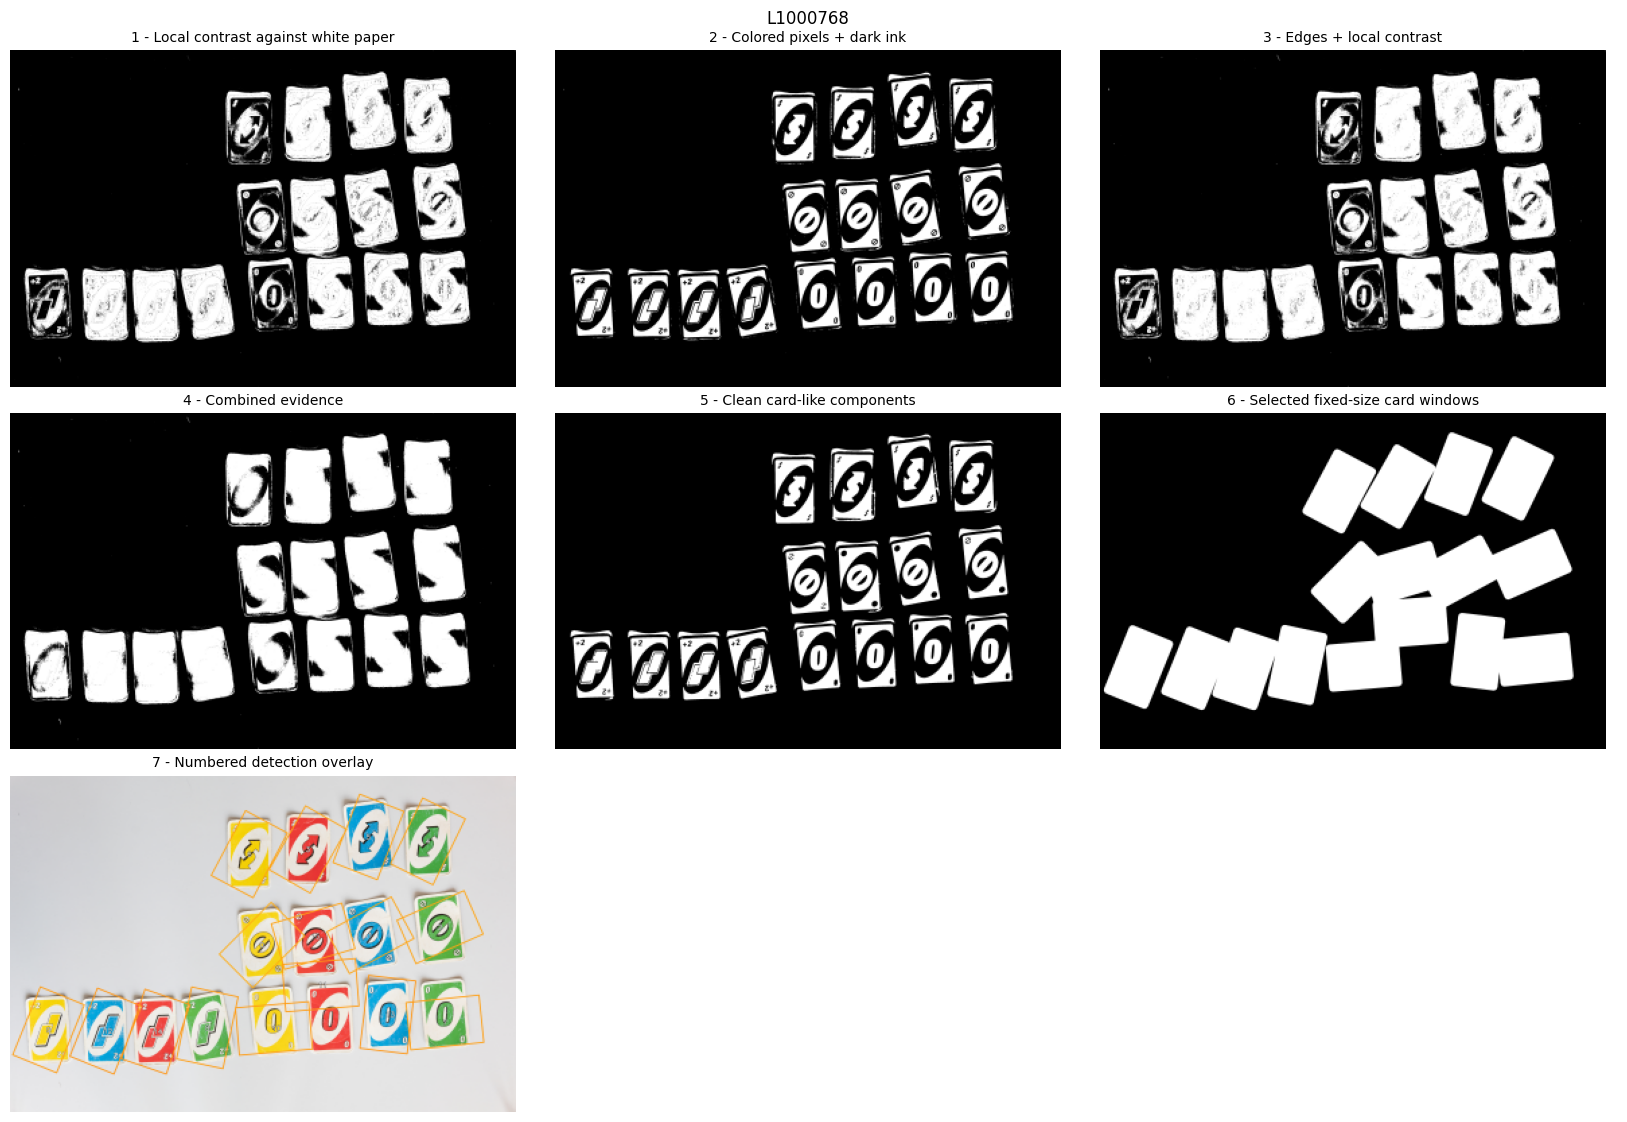

In [ ]:
plot_pipeline_steps(color_rgb, pipeline_steps, preview_image_name)

In [ ]:
selected = list(image_components.keys()) if images_to_process is None else images_to_process

results: dict[str, object] = {}
for name in selected:
    r = extract_reference_card_assets(
        image_name=name,
        num_components=image_components[name],
        **pipeline_kwargs,
        **extract_kwargs,
    )
    results[name] = r
    print(f"{name}: {len(r.components)} components, {len(r.masks)} masks, {len(r.crops)} crops")


L1000765: 12 components, 12 masks, 12 crops
L1000766: 12 components, 12 masks, 12 crops
L1000767: 14 components, 14 masks, 14 crops
L1000768: 16 components, 16 masks, 16 crops


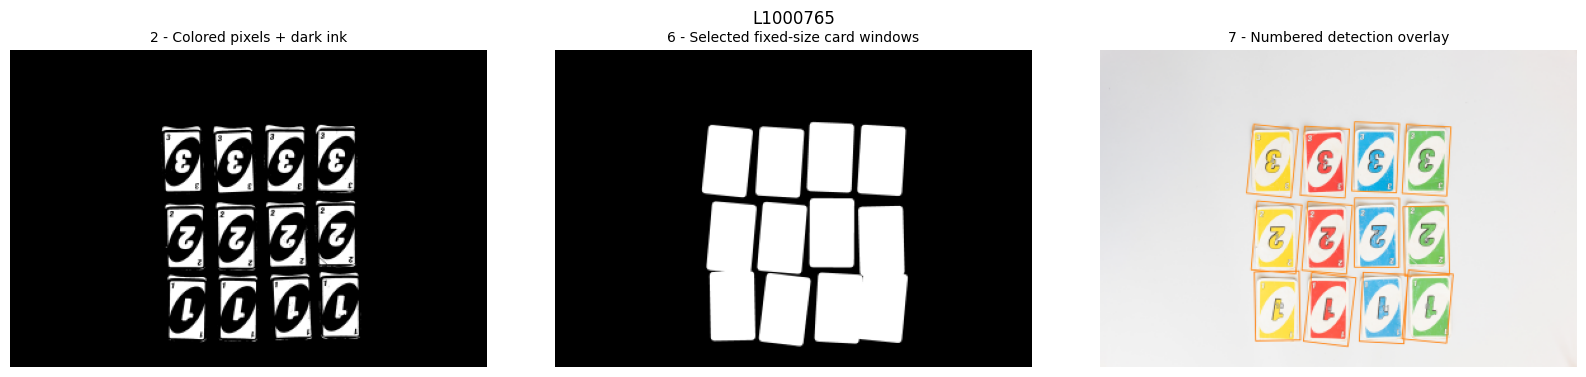

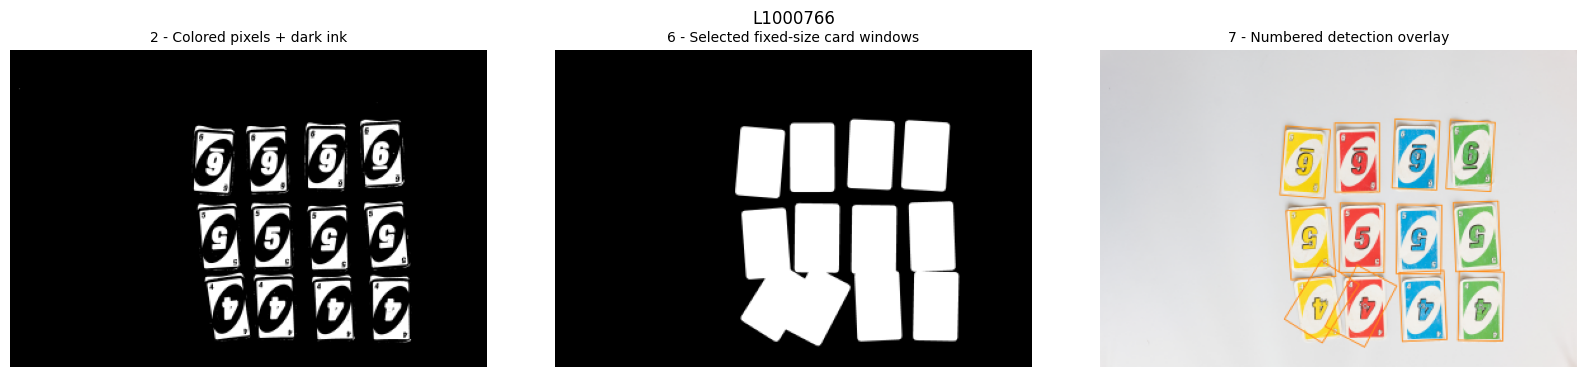

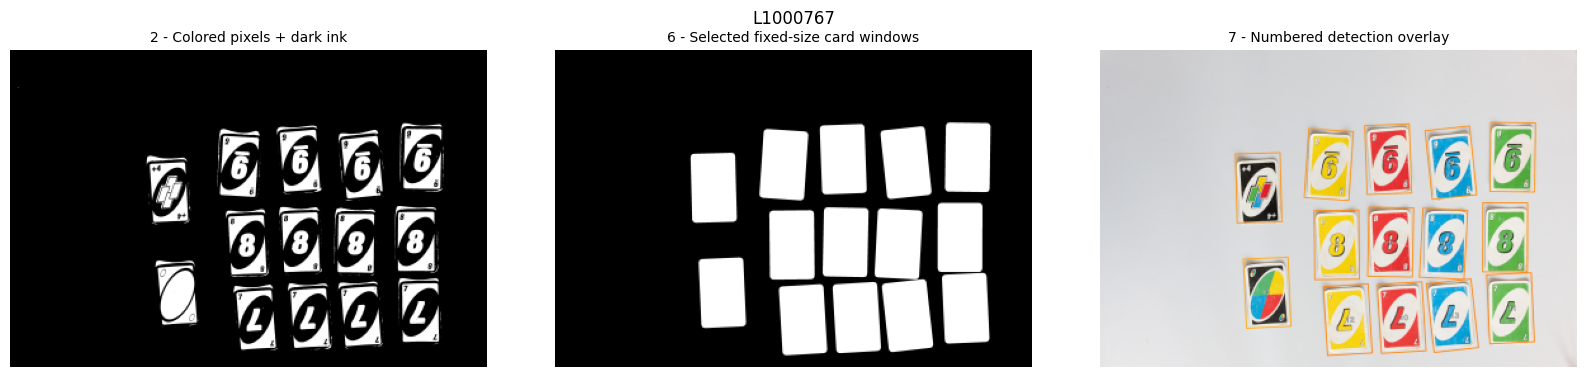

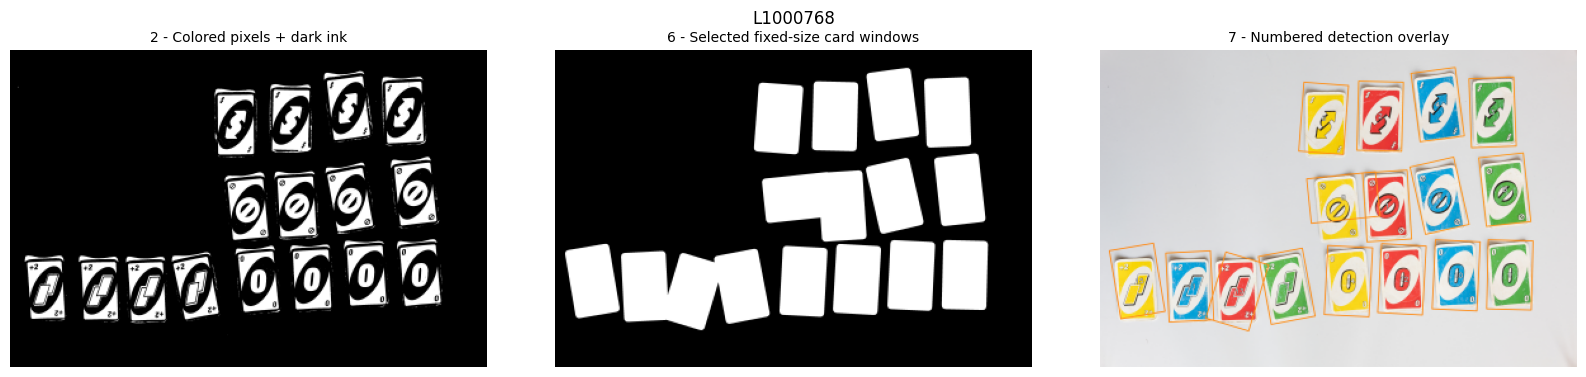

In [ ]:
for name in results:
    _, color_rgb = load_reference_image(name)
    pipeline_steps = _mask_pipeline_steps(
        color_rgb,
        num_components=image_components[name],
        **pipeline_kwargs,
    )
    plot_pipeline_steps(color_rgb, pipeline_steps, title=name)